In [1]:
import yfinance as yf
import pandas as pd
import warnings
warnings.filterwarnings("ignore")
stocks = ["RELIANCE.NS", "TCS.NS", "HDFCBANK.NS", "INFY.NS"]

raw = yf.download(
    tickers=stocks,
    start="2020-01-01",
    end="2024-01-01",
    group_by="column",    
    auto_adjust=False,    
    progress=True
)

print("RAW COLUMNS (first 20):")
print(list(raw.columns)[:20])
print("\nIs MultiIndex?", isinstance(raw.columns, pd.MultiIndex))

[*********************100%***********************]  4 of 4 completed

RAW COLUMNS (first 20):
[('Adj Close', 'HDFCBANK.NS'), ('Adj Close', 'INFY.NS'), ('Adj Close', 'RELIANCE.NS'), ('Adj Close', 'TCS.NS'), ('Close', 'HDFCBANK.NS'), ('Close', 'INFY.NS'), ('Close', 'RELIANCE.NS'), ('Close', 'TCS.NS'), ('High', 'HDFCBANK.NS'), ('High', 'INFY.NS'), ('High', 'RELIANCE.NS'), ('High', 'TCS.NS'), ('Low', 'HDFCBANK.NS'), ('Low', 'INFY.NS'), ('Low', 'RELIANCE.NS'), ('Low', 'TCS.NS'), ('Open', 'HDFCBANK.NS'), ('Open', 'INFY.NS'), ('Open', 'RELIANCE.NS'), ('Open', 'TCS.NS')]

Is MultiIndex? True


# Extract Prices Correctly

In [2]:
if isinstance(raw.columns, pd.MultiIndex):
    level0 = raw.columns.get_level_values(0).unique().tolist()
    print("\nAvailable fields:", level0)

    if "Adj Close" in level0:
        prices = raw["Adj Close"].copy()
        price_field_used = "Adj Close"
    elif "Close" in level0:
        prices = raw["Close"].copy()
        price_field_used = "Close"
    else:
        raise ValueError(f"No Adj Close/Close found. Fields present: {level0}")

else:
    # Single-index columns case (rare for multi-ticker, but handle it)
    if "Adj Close" in raw.columns:
        prices = raw["Adj Close"].to_frame()
        price_field_used = "Adj Close"
    elif "Close" in raw.columns:
        prices = raw["Close"].to_frame()
        price_field_used = "Close"
    else:
        raise ValueError(f"No Adj Close/Close found. Columns: {raw.columns.tolist()}")

print(f"\n Using: {price_field_used}")
print(prices.head())
print("\nMissing values per ticker:")
print(prices.isna().sum())


Available fields: ['Adj Close', 'Close', 'High', 'Low', 'Open', 'Volume']

 Using: Adj Close
Ticker      HDFCBANK.NS     INFY.NS  RELIANCE.NS       TCS.NS
Date                                                         
2020-01-01   605.529358  633.151123   675.324219  1866.114014
2020-01-02   609.389160  631.303772   686.821228  1857.547729
2020-01-03   600.698853  641.013489   687.648804  1894.566895
2020-01-06   587.698792  634.869690   671.700623  1894.394409
2020-01-07   597.004761  625.460693   682.034485  1899.043701

Missing values per ticker:
Ticker
HDFCBANK.NS    0
INFY.NS        0
RELIANCE.NS    0
TCS.NS         0
dtype: int64


# Clean the Data

In [3]:
prices = prices.sort_index()
prices = prices.dropna(how="all")      # drop rows where all tickers are NaN
prices = prices.ffill().dropna()       # fill small gaps then drop remaining

print("\n Cleaned prices shape:", prices.shape)
print(prices.head())


 Cleaned prices shape: (992, 4)
Ticker      HDFCBANK.NS     INFY.NS  RELIANCE.NS       TCS.NS
Date                                                         
2020-01-01   605.529358  633.151123   675.324219  1866.114014
2020-01-02   609.389160  631.303772   686.821228  1857.547729
2020-01-03   600.698853  641.013489   687.648804  1894.566895
2020-01-06   587.698792  634.869690   671.700623  1894.394409
2020-01-07   597.004761  625.460693   682.034485  1899.043701


In [4]:
import os

os.makedirs("data", exist_ok=True)  # creates data/ if missing
prices.to_csv("data/prices.csv")
print(" Saved: data/prices.csv")

 Saved: data/prices.csv


# Returns Engine

In [5]:
import pandas as pd
import numpy as np
from pathlib import Path

# --- Project paths (robust on Windows) ---
PROJECT_DIR = Path(r"C:\Users\deven\PYTHON\AlphaPulse")
DATA_DIR = PROJECT_DIR / "data"
DATA_DIR.mkdir(parents=True, exist_ok=True)

PRICES_FILE = DATA_DIR / "prices.csv"
RETURNS_FILE = DATA_DIR / "returns.csv"
LOG_RETURNS_FILE = DATA_DIR / "log_returns.csv"

# --- Load prices (must be a CSV file, not a folder) ---
if not PRICES_FILE.exists():
    raise FileNotFoundError(f" prices.csv not found here: {PRICES_FILE}\n"
                            f"Check that you saved it as data/prices.csv")

prices = pd.read_csv(PRICES_FILE, index_col=0, parse_dates=True)

# --- Clean + validate ---
prices = prices.sort_index()
prices = prices.dropna(how="all").ffill().dropna()

# --- Returns engines ---
returns = prices.pct_change().dropna()
log_returns = np.log(prices / prices.shift(1)).dropna()

print(" Prices shape:", prices.shape)
print(" Returns preview:")
print(returns.head())

# --- Save outputs ---
returns.to_csv(RETURNS_FILE)
log_returns.to_csv(LOG_RETURNS_FILE)

print(f" Saved: {RETURNS_FILE}")
print(f" Saved: {LOG_RETURNS_FILE}")

 Prices shape: (992, 4)
 Returns preview:
            HDFCBANK.NS   INFY.NS  RELIANCE.NS    TCS.NS
Date                                                    
2020-01-02     0.006374 -0.002918     0.017025 -0.004591
2020-01-03    -0.014261  0.015380     0.001205  0.019929
2020-01-06    -0.021642 -0.009584    -0.023192 -0.000091
2020-01-07     0.015835 -0.014820     0.015385  0.002454
2020-01-08    -0.002618 -0.013326    -0.007510  0.022395
 Saved: C:\Users\deven\PYTHON\AlphaPulse\data\returns.csv
 Saved: C:\Users\deven\PYTHON\AlphaPulse\data\log_returns.csv


# Volatility + Covariance

In [6]:
import pandas as pd
import numpy as np
from pathlib import Path


PROJECT_DIR = Path(r"C:\Users\deven\PYTHON\AlphaPulse")
DATA_DIR = PROJECT_DIR / "data"

RETURNS_FILE = DATA_DIR / "returns.csv"
VOL_FILE = DATA_DIR / "vol_annual.csv"
COV_FILE = DATA_DIR / "cov_annual.csv"


if not RETURNS_FILE.exists():
    raise FileNotFoundError(f" returns.csv not found at {RETURNS_FILE}")

returns = pd.read_csv(RETURNS_FILE, index_col=0, parse_dates=True)

print("Data loaded:", returns.shape)


ANN = 252  # trading days per year

# Annual volatility per stock
vol_annual = returns.std() * np.sqrt(ANN)

# Annual covariance matrix
cov_annual = returns.cov() * ANN


print("\n Annualized Volatility (Highest Risk First)")
print(vol_annual.sort_values(ascending=False))

print("\n Covariance Matrix Preview")
print(cov_annual.iloc[:3, :3])

# ================================
# SAVE FILES
# ================================
vol_annual.to_csv(VOL_FILE)
cov_annual.to_csv(COV_FILE)

print(f"\n Saved: {VOL_FILE}")
print(f" Saved: {COV_FILE}")

Data loaded: (991, 4)

 Annualized Volatility (Highest Risk First)
RELIANCE.NS    0.311976
INFY.NS        0.289702
HDFCBANK.NS    0.283579
TCS.NS         0.252350
dtype: float64

 Covariance Matrix Preview
             HDFCBANK.NS   INFY.NS  RELIANCE.NS
HDFCBANK.NS     0.080417  0.032730     0.040820
INFY.NS         0.032730  0.083927     0.034817
RELIANCE.NS     0.040820  0.034817     0.097329

 Saved: C:\Users\deven\PYTHON\AlphaPulse\data\vol_annual.csv
 Saved: C:\Users\deven\PYTHON\AlphaPulse\data\cov_annual.csv


# Correlation Heatmap

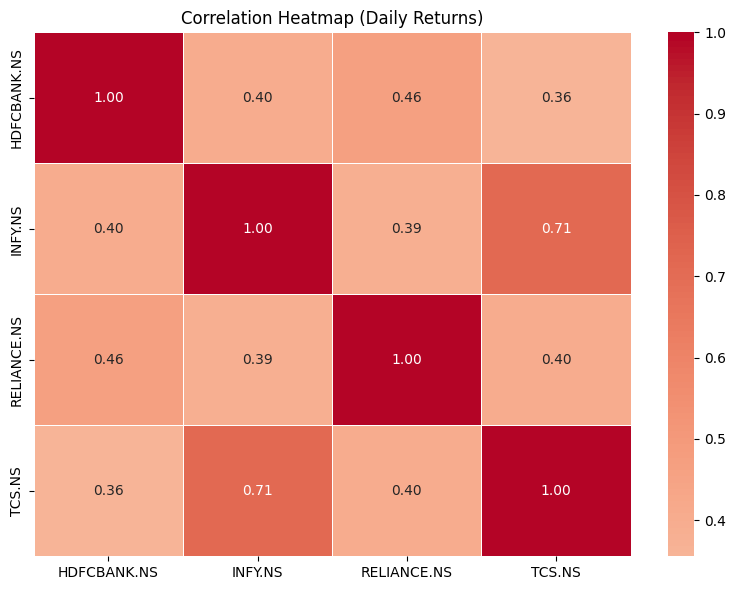

In [7]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from pathlib import Path

PROJECT_DIR = Path(r"C:\Users\deven\PYTHON\AlphaPulse")
DATA_DIR = PROJECT_DIR / "data"
RETURNS_FILE = DATA_DIR / "returns.csv"

if not RETURNS_FILE.exists():
    raise FileNotFoundError(f"returns.csv not found at {RETURNS_FILE}")

returns = pd.read_csv(RETURNS_FILE, index_col=0, parse_dates=True)

returns = returns.sort_index()
returns = returns.dropna(how="all")

corr = returns.corr()

plt.figure(figsize=(8, 6))
sns.heatmap(
    corr,
    annot=True,
    cmap="coolwarm",
    center=0,
    linewidths=0.5,
    fmt=".2f"
)
plt.title("Correlation Heatmap (Daily Returns)")
plt.tight_layout()
plt.show()

# Rolling 30D Volatility

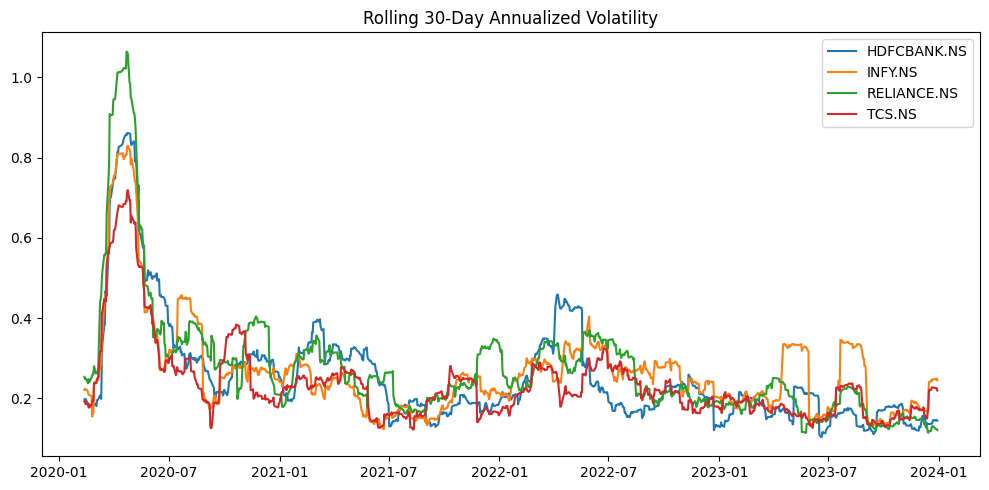

Saved: C:\Users\deven\PYTHON\AlphaPulse\data\rolling_vol_30d.csv


In [8]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

PROJECT_DIR = Path(r"C:\Users\deven\PYTHON\AlphaPulse")
DATA_DIR = PROJECT_DIR / "data"
RETURNS_FILE = DATA_DIR / "returns.csv"
ROLLING_VOL_FILE = DATA_DIR / "rolling_vol_30d.csv"

if not RETURNS_FILE.exists():
    raise FileNotFoundError(f"returns.csv not found at {RETURNS_FILE}")

returns = pd.read_csv(RETURNS_FILE, index_col=0, parse_dates=True)

returns = returns.sort_index()
returns = returns.dropna(how="all")

rolling_vol_30d = returns.rolling(window=30).std() * np.sqrt(252)

plt.figure(figsize=(10, 5))
for col in rolling_vol_30d.columns:
    plt.plot(rolling_vol_30d.index, rolling_vol_30d[col], label=col)

plt.title("Rolling 30-Day Annualized Volatility")
plt.legend()
plt.tight_layout()
plt.show()

rolling_vol_30d.to_csv(ROLLING_VOL_FILE)
print(f"Saved: {ROLLING_VOL_FILE}")

In [9]:
print(prices.shape)
print(prices.columns)

(992, 4)
Index(['HDFCBANK.NS', 'INFY.NS', 'RELIANCE.NS', 'TCS.NS'], dtype='object')


# Portfolio Engine (Weights + Portfolio Returns)

In [10]:
import pandas as pd
import numpy as np
from pathlib import Path

PROJECT_DIR = Path(r"C:\Users\deven\PYTHON\AlphaPulse")
DATA_DIR = PROJECT_DIR / "data"

RETURNS_FILE = DATA_DIR / "returns.csv"
PORT_RET_FILE = DATA_DIR / "portfolio_returns.csv"

if not RETURNS_FILE.exists():
    raise FileNotFoundError(f"returns.csv not found at {RETURNS_FILE}")

returns = pd.read_csv(RETURNS_FILE, index_col=0, parse_dates=True)

returns = returns.sort_index().dropna(how="all")

w = np.array([0.25, 0.25, 0.25, 0.25])

if len(w) != returns.shape[1]:
    raise ValueError("Number of weights must match number of assets")

if not np.isclose(w.sum(), 1.0):
    raise ValueError("Weights must sum to 1")

print("Assets:", returns.columns.tolist())
print("Weights sum:", w.sum())

portfolio_returns = returns @ w
portfolio_returns.name = "portfolio_return"

print(portfolio_returns.head())

portfolio_returns.to_csv(PORT_RET_FILE)
print(f"Saved: {PORT_RET_FILE}")

Assets: ['HDFCBANK.NS', 'INFY.NS', 'RELIANCE.NS', 'TCS.NS']
Weights sum: 1.0
Date
2020-01-02    0.003973
2020-01-03    0.005563
2020-01-06   -0.013627
2020-01-07    0.004713
2020-01-08   -0.000265
Name: portfolio_return, dtype: float64
Saved: C:\Users\deven\PYTHON\AlphaPulse\data\portfolio_returns.csv


# Portfolio Volatility

In [11]:
import pandas as pd
import numpy as np
from pathlib import Path

PROJECT_DIR = Path(r"C:\Users\deven\PYTHON\AlphaPulse")
DATA_DIR = PROJECT_DIR / "data"

RETURNS_FILE = DATA_DIR / "returns.csv"
PORT_VOL_FILE = DATA_DIR / "portfolio_volatility.csv"

if not RETURNS_FILE.exists():
    raise FileNotFoundError(f"returns.csv not found at {RETURNS_FILE}")

returns = pd.read_csv(RETURNS_FILE, index_col=0, parse_dates=True)
returns = returns.sort_index().dropna(how="all")

ANN = 252

w = np.array([0.25, 0.25, 0.25, 0.25])

if len(w) != returns.shape[1]:
    raise ValueError("Number of weights must match number of assets")

if not np.isclose(w.sum(), 1.0):
    raise ValueError("Weights must sum to 1")

cov_daily = returns.cov()
cov_annual = cov_daily * ANN

port_var_daily = w.T @ cov_daily.values @ w
port_vol_daily = np.sqrt(port_var_daily)

port_var_annual = w.T @ cov_annual.values @ w
port_vol_annual = np.sqrt(port_var_annual)

print("Portfolio daily volatility:", port_vol_daily)
print("Portfolio annual volatility:", port_vol_annual)

vol_df = pd.DataFrame({
    "Metric": ["Daily Volatility", "Annual Volatility"],
    "Value": [port_vol_daily, port_vol_annual]
})

vol_df.to_csv(PORT_VOL_FILE, index=False)
print(f"Saved: {PORT_VOL_FILE}")

Portfolio daily volatility: 0.013735254308533826
Portfolio annual volatility: 0.21804040256765364
Saved: C:\Users\deven\PYTHON\AlphaPulse\data\portfolio_volatility.csv


# VaR (Historical + Parametric)

Historical VaR (non-parametric)

In [12]:
import pandas as pd
import numpy as np
from pathlib import Path

PROJECT_DIR = Path(r"C:\Users\deven\PYTHON\AlphaPulse")
DATA_DIR = PROJECT_DIR / "data"

PORT_RET_FILE = DATA_DIR / "portfolio_returns.csv"
HIST_FILE = DATA_DIR / "historical_var.csv"
PARAM_FILE = DATA_DIR / "parametric_var.csv"

portfolio_returns = pd.read_csv(PORT_RET_FILE, index_col=0, parse_dates=True)["portfolio_return"]
portfolio_returns = portfolio_returns.dropna()

alpha = 0.05

hist_var = -np.quantile(portfolio_returns, alpha)

hist_df = pd.DataFrame({
    "Historical_VaR_95": [hist_var]
})
hist_df.to_csv(HIST_FILE, index=False)

print("Historical VaR (95%):", hist_var)
print(f"Saved: {HIST_FILE}")

Historical VaR (95%): 0.018219745716019448
Saved: C:\Users\deven\PYTHON\AlphaPulse\data\historical_var.csv


Parametric VaR (Normal assumption)

In [13]:
import pandas as pd
import numpy as np
from scipy.stats import norm
from pathlib import Path

PROJECT_DIR = Path(r"C:\Users\deven\PYTHON\AlphaPulse")
DATA_DIR = PROJECT_DIR / "data"

PORT_RET_FILE = DATA_DIR / "portfolio_returns.csv"
PARAM_FILE = DATA_DIR / "parametric_var.csv"

portfolio_returns = pd.read_csv(PORT_RET_FILE, index_col=0, parse_dates=True)["portfolio_return"]
portfolio_returns = portfolio_returns.dropna()

alpha = 0.05

mu = portfolio_returns.mean()
sigma = portfolio_returns.std()
z = norm.ppf(alpha)

param_var = -(mu + z * sigma)

param_df = pd.DataFrame({
    "Parametric_VaR_95": [param_var]
})
param_df.to_csv(PARAM_FILE, index=False)

print("Parametric VaR (95%):", param_var)
print(f"Saved: {PARAM_FILE}")

Parametric VaR (95%): 0.02181853503014001
Saved: C:\Users\deven\PYTHON\AlphaPulse\data\parametric_var.csv


# Monte Carlo VaR (10,000 runs)

In [14]:
import pandas as pd
import numpy as np
from pathlib import Path

PROJECT_DIR = Path(r"C:\Users\deven\PYTHON\AlphaPulse")
DATA_DIR = PROJECT_DIR / "data"

PORT_RET_FILE = DATA_DIR / "portfolio_returns.csv"
MC_VAR_FILE = DATA_DIR / "monte_carlo_var.csv"

if not PORT_RET_FILE.exists():
    raise FileNotFoundError(f"portfolio_returns.csv not found at {PORT_RET_FILE}")

portfolio_returns = pd.read_csv(PORT_RET_FILE, index_col=0, parse_dates=True)["portfolio_return"]
portfolio_returns = portfolio_returns.dropna()

mu = portfolio_returns.mean()
sigma = portfolio_returns.std()

n_sims = 10000
simulated = np.random.normal(loc=mu, scale=sigma, size=n_sims)

alpha = 0.05
mc_var = -np.quantile(simulated, alpha)

print("Monte Carlo VaR (95%, 10k sims):", mc_var)

mc_df = pd.DataFrame({
    "MonteCarlo_VaR_95": [mc_var]
})

mc_df.to_csv(MC_VAR_FILE, index=False)
print(f"Saved: {MC_VAR_FILE}")

Monte Carlo VaR (95%, 10k sims): 0.022141493707731854
Saved: C:\Users\deven\PYTHON\AlphaPulse\data\monte_carlo_var.csv


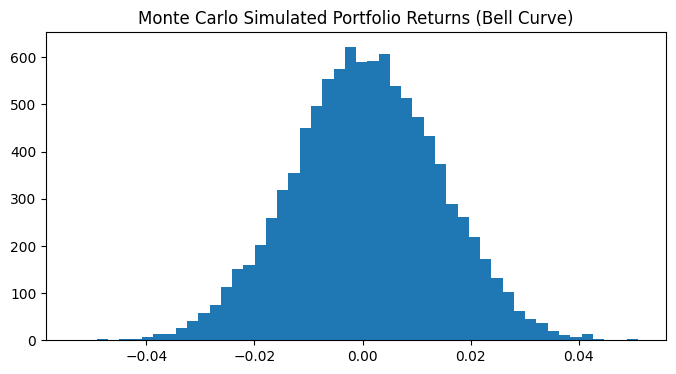

In [15]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,4))
plt.hist(simulated, bins=50)
plt.title("Monte Carlo Simulated Portfolio Returns (Bell Curve)")
plt.show()

# Convert VaR into REAL MONEY

In [16]:
import pandas as pd
from pathlib import Path

PROJECT_DIR = Path(r"C:\Users\deven\PYTHON\AlphaPulse")
DATA_DIR = PROJECT_DIR / "data"

HIST_FILE = DATA_DIR / "historical_var.csv"
MC_FILE = DATA_DIR / "monte_carlo_var.csv"
REAL_VAR_FILE = DATA_DIR / "real_money_var.csv"

if not HIST_FILE.exists():
    raise FileNotFoundError(f"historical_var.csv not found at {HIST_FILE}")

if not MC_FILE.exists():
    raise FileNotFoundError(f"monte_carlo_var.csv not found at {MC_FILE}")

hist_var = pd.read_csv(HIST_FILE)["Historical_VaR_95"].iloc[0]
mc_var = pd.read_csv(MC_FILE)["MonteCarlo_VaR_95"].iloc[0]

portfolio_value = 1_000_000

hist_var_rs = hist_var * portfolio_value
mc_var_rs = mc_var * portfolio_value

print("REAL MONEY VaR")
print(f"Portfolio Value: ₹{portfolio_value:,.0f}")
print(f"Historical VaR (₹): {hist_var_rs:,.0f}")
print(f"Monte Carlo VaR (₹): {mc_var_rs:,.0f}")

real_var_df = pd.DataFrame({
    "Portfolio_Value": [portfolio_value],
    "Historical_VaR_Rs": [hist_var_rs],
    "MonteCarlo_VaR_Rs": [mc_var_rs]
})

real_var_df.to_csv(REAL_VAR_FILE, index=False)
print(f"Saved: {REAL_VAR_FILE}")

REAL MONEY VaR
Portfolio Value: ₹1,000,000
Historical VaR (₹): 18,220
Monte Carlo VaR (₹): 22,141
Saved: C:\Users\deven\PYTHON\AlphaPulse\data\real_money_var.csv


# REAL MONTE CARLO (MULTIVARIATE)

In [17]:
import pandas as pd
import numpy as np
from pathlib import Path

PROJECT_DIR = Path(r"C:\Users\deven\PYTHON\AlphaPulse")
DATA_DIR = PROJECT_DIR / "data"

RETURNS_FILE = DATA_DIR / "returns.csv"
ADV_MC_FILE = DATA_DIR / "advanced_monte_carlo_var.csv"

if not RETURNS_FILE.exists():
    raise FileNotFoundError(f"returns.csv not found at {RETURNS_FILE}")

returns = pd.read_csv(RETURNS_FILE, index_col=0, parse_dates=True)
returns = returns.sort_index().dropna(how="all")

w = np.array([0.25, 0.25, 0.25, 0.25])

if len(w) != returns.shape[1]:
    raise ValueError("Number of weights must match number of assets")

if not np.isclose(w.sum(), 1.0):
    raise ValueError("Weights must sum to 1")

mean_returns = returns.mean().values
cov_matrix = returns.cov().values

n_sims = 10000

simulated_returns = np.random.multivariate_normal(
    mean=mean_returns,
    cov=cov_matrix,
    size=n_sims
)

portfolio_simulated = simulated_returns @ w

alpha = 0.05
mc_var_advanced = -np.quantile(portfolio_simulated, alpha)

print("Advanced Monte Carlo VaR (95%):", mc_var_advanced)

adv_mc_df = pd.DataFrame({
    "Advanced_MonteCarlo_VaR_95": [mc_var_advanced]
})

adv_mc_df.to_csv(ADV_MC_FILE, index=False)
print(f"Saved: {ADV_MC_FILE}")

Advanced Monte Carlo VaR (95%): 0.02196158019630874
Saved: C:\Users\deven\PYTHON\AlphaPulse\data\advanced_monte_carlo_var.csv


# Efficient Frontier

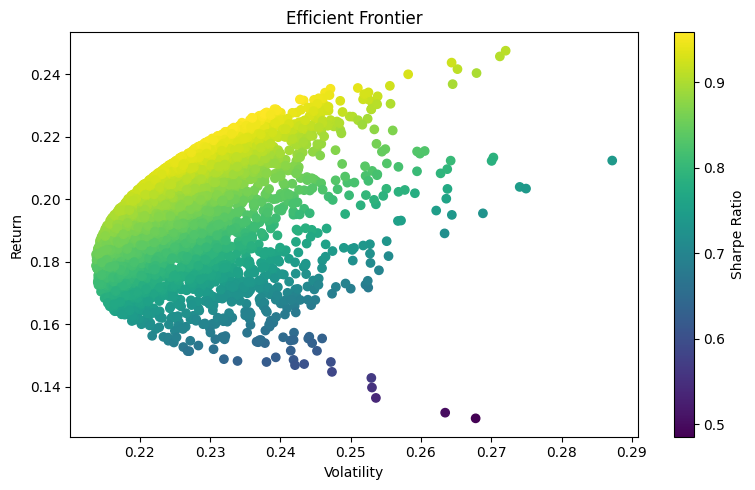

Saved: C:\Users\deven\PYTHON\AlphaPulse\data\efficient_frontier_points.csv


In [18]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

PROJECT_DIR = Path(r"C:\Users\deven\PYTHON\AlphaPulse")
DATA_DIR = PROJECT_DIR / "data"

RETURNS_FILE = DATA_DIR / "returns.csv"
EFF_FILE = DATA_DIR / "efficient_frontier_points.csv"

if not RETURNS_FILE.exists():
    raise FileNotFoundError(f"returns.csv not found at {RETURNS_FILE}")

returns = pd.read_csv(RETURNS_FILE, index_col=0, parse_dates=True)
returns = returns.sort_index().dropna(how="all")

mean_returns = returns.mean() * 252
cov_matrix = returns.cov() * 252

n_portfolios = 5000
results = []

for _ in range(n_portfolios):
    w = np.random.random(len(mean_returns))
    w /= w.sum()
    
    ret = np.dot(w, mean_returns.values)
    vol = np.sqrt(w.T @ cov_matrix.values @ w)
    sharpe = ret / vol if vol != 0 else 0
    
    results.append([ret, vol, sharpe])

results = np.array(results)

ef_df = pd.DataFrame(results, columns=["Return", "Volatility", "Sharpe"])
ef_df.to_csv(EFF_FILE, index=False)

plt.figure(figsize=(8,5))
plt.scatter(results[:,1], results[:,0], c=results[:,2])
plt.xlabel("Volatility")
plt.ylabel("Return")
plt.title("Efficient Frontier")
plt.colorbar(label="Sharpe Ratio")
plt.tight_layout()
plt.show()

print(f"Saved: {EFF_FILE}")

# Feature 1 — Drawdown

In [19]:
cum_returns = (1 + portfolio_returns).cumprod()
peak = cum_returns.cummax()
drawdown = (cum_returns - peak) / peak

print("Max Drawdown:", drawdown.min())

Max Drawdown: -0.34884551554156185


# Feature 2 — Sharpe Ratio

In [20]:
rf = 0.05/252
sharpe = (portfolio_returns.mean() - rf) / portfolio_returns.std()
print("Sharpe Ratio:", sharpe * np.sqrt(252))

Sharpe Ratio: 0.6651742202496953


# Feature 3 — Stress Test (2008 crash mode)

In [21]:
stress = portfolio_returns.copy()
stress *= 3  # simulate crash volatility
stress_var = -np.quantile(stress, 0.05)
print("Crash VaR:", stress_var)

Crash VaR: 0.05465923714805835


# Feature 4 — Risk Level Engine

In [22]:
if mc_var > 0.03:
    print("HIGH RISK PORTFOLIO")
elif mc_var > 0.015:
    print("MEDIUM RISK")
else:
    print("LOW RISK")

MEDIUM RISK


# Feature 5 — Portfolio Allocation Pie Chart

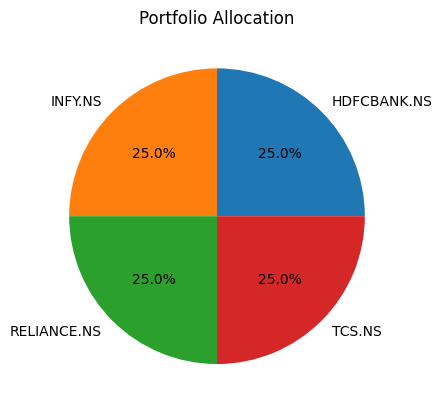

In [23]:
import matplotlib.pyplot as plt

labels = returns.columns
weights = [0.25,0.25,0.25,0.25]

plt.pie(weights, labels=labels, autopct='%1.1f%%')
plt.title("Portfolio Allocation")
plt.show()